In [10]:
pip install xgboost

  Using cached xgboost-3.1.3-py3-none-win_amd64.whl.metadata (2.0 kB)
Using cached xgboost-3.1.3-py3-none-win_amd64.whl (72.0 MB)
Note: you may need to restart the kernel to use updated packages.


In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import shapiro, kstest, anderson


#Grab data and put numerical vals in one table
#################################################################################################################
dataset_as_given = pd.read_csv(r"d:\Desktop\Practice Python\21.gym_members_exercise_tracking.csv")
#print(dataset_as_given)

# Get column names
column_names = dataset_as_given.columns
#print(column_names)

desired = ["Age", "Weight (kg)", "Height (m)", "Max_BPM", "Avg_BPM", "Resting_BPM", 
           "Session_Duration (hours)", "Calories_Burned", "Fat_Percentage", "Water_Intake (liters)", "Workout_Frequency (days/week)", "Experience_Level", "BMI"]

dataset_as_given_numeric = dataset_as_given[desired]



#Get Rid of Outliers
#################################################################################################################

# Copy the dataset so you keep the original intact
cleaned_df = dataset_as_given.copy()

# Select numeric columns
numeric_cols = cleaned_df.select_dtypes(include=['int64', 'float64']).columns

for col in numeric_cols:
    Q1 = cleaned_df[col].quantile(0.25)
    Q3 = cleaned_df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Filter out outliers
    cleaned_df = cleaned_df[(cleaned_df[col] >= lower_bound) & (cleaned_df[col] <= upper_bound)]



print("Original rows:", dataset_as_given.shape[0])
print("Cleaned rows:", cleaned_df.shape[0])
print("Rows removed:", dataset_as_given.shape[0] - cleaned_df.shape[0])


#################################################################################################################

encoded_df = cleaned_df.copy()

encoded_df['Gender'] = encoded_df['Gender'].map({
    'Male': 1,
    'Female': 0
})

workout_dummies = pd.get_dummies(encoded_df['Workout_Type'], prefix='Workout', drop_first=True)
encoded_df = pd.concat([encoded_df.drop(columns=['Workout_Type']), workout_dummies], axis=1)




Original rows: 973
Cleaned rows: 931
Rows removed: 42


In [2]:
# ============================================================
#   TRAIN/TEST SPLIT + SCALING
#   This prepares your data for any ML model
# ============================================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ------------------------------------------------------------
# 1. Define X (features) and y (target)
# ------------------------------------------------------------
# Gender must already be encoded as 0/1 in encoded_df
X = encoded_df.drop(columns=['Gender'])
y = encoded_df['Gender']

# ------------------------------------------------------------
# 2. Train/Test Split
# ------------------------------------------------------------
# test_size=0.2 means 20% of data is held out for testing
# random_state=42 ensures reproducibility
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ------------------------------------------------------------
# 3. Scale the numeric features
# ------------------------------------------------------------
# Scaling helps models like Logistic Regression, SVM, KNN, Neural Networks
# Tree-based models (Random Forest, XGBoost) do NOT require scaling,
# but scaling does not harm them.
scaler = StandardScaler()

# Fit on training data ONLY, then transform both sets
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ------------------------------------------------------------
# 4. Optional: Print shapes to confirm everything looks right
# ------------------------------------------------------------
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

print("\nScaled versions created: X_train_scaled, X_test_scaled")


X_train shape: (744, 16)
X_test shape: (187, 16)
y_train shape: (744,)
y_test shape: (187,)

Scaled versions created: X_train_scaled, X_test_scaled


Decision Tree<br><br>

A Decision Tree helps us to make decisions by mapping out different choices and their possible outcomes. It is used in machine learning for tasks like classification and prediction. <br><br>

A Decision Tree helps us make decisions by showing different options and how they are related. It has a tree-like structure that starts with one main question called the root node which represents the entire dataset. From there, the tree branchesout into different possibilities based on features in the data.<br><br>

- Root Note -> Starting point representing the whole dataset<br>
- Bracnhes -> Lines connecting nodes showing the flow from one decision to another<br>
- Internal Nodes -> Points where decisions are made based on data features<br>
- Leaf Nodes -> End points of the tree where the final decision or prediction is made<br><br>

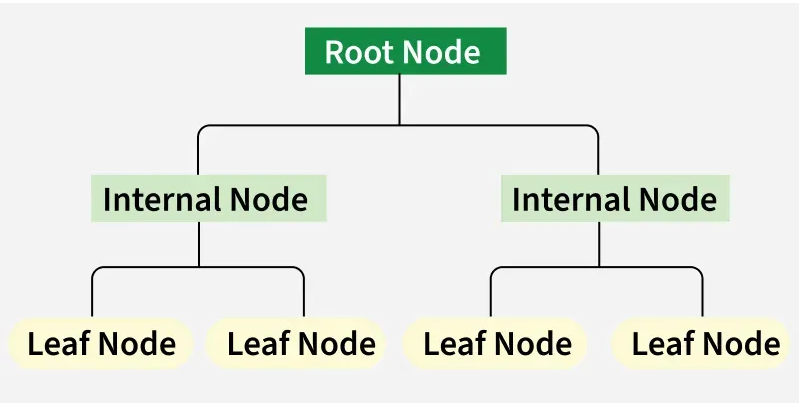<br><br>

A Decision Tree also helps with decision-making by showing possible outcomes clearly. By looking at the 'branches' we can quickly compare options and figure out the best choice.<br><br>

There are mainly two types of Decision Trees based o the target variable:<br><br>

1. Classification Trees -> Used for predicting categorical outcomes like spam or not spam. These trees split the data based on features to classify data into predefined categories.<br><br>

2. Regression Trees -> Used for predicting continous outcomes like predicting house prices. Instead of assigning categories, it provides numberical predictions based on the input features.<br><br>

How do Decision Trees Work?<br><br>

1. Start with the Root Node -> It bagins with a main questions at the root node which is derived from the dataset's features<br><br>

2. Ask Yes/No Questions -> From the root, the tree asks a series of yes/no questions to split the data into subsets based on specific attributes<br><br>

3. Branching Based on Answers -> Each question leads to different braches:<br>
- If the answer is 'YES', the tree follows one path<br>
- If the answer is 'NO', the tree follows another path<br><br>

4. Continue Splitting -> This branching continues through further decisions helps in reducing the data down step-by-step<br><br>

5. Reach the Leaf Node -> The process ends when there are no more useful questions to ask leading to the leaf node where the final decision or prediction is made<br><br>

Let us look at a simple example to see how it works. Imagine we need to decide whether to drink coffee based on the time of the day and how tired we feel. The tree first checks the time:<br><br>

1. In the Morning -> It asks 'Tired?'<br><br>

- If 'YES', the tree suggests drinking coffee<br>
- If 'NO', it says no coffee is needed<br><br>

2. In the afternoon -> It asks again 'Tired?'<br><br>

- If 'YES', it suggest drinking coffee<br>
- If 'NO', no coffee is needed<br><br>

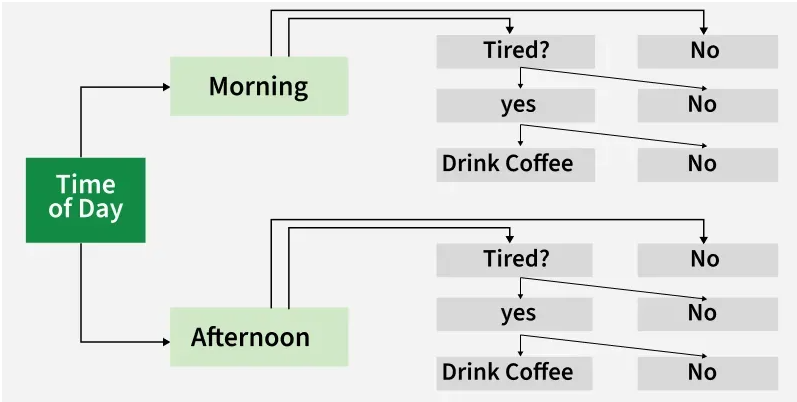<br><br>

Splitting Criteria in Decision Trees<br><br>

In a Decision Tree, the process of splitting data at each node is important. The splitting criteria finds the best feature to split the data on. Common splitting criteria include Gini Impurity and Entropy.<br><br>

- Gini Impurity -> This criterian measures how 'impure' a node is. The lower the Gini impurity the better the feature splits the data into distinct categories<br>
- Entropy -> This measures the amount of uncertanty or disorder in the data. The tree tries to reduce the emtropy by splitting the data on features that provide the most information about the target variable<br><br>

These criteria help decide which features are useful for making the best split at each decision point in the tree<br><br>

Prunning in Decision Trees<br><br>

- Prunning in an importnat technique used to prevent overfitting in Decision Trees. Overfitting occurs when a tree becomes too deep and starts to memorize the training data rather than learning general patterns. This leads to poor performance on new, unseen data<br>
- This technique reduces the complexity of the tree by removing branches that have little predictive power. It improves model performance by helping the tree generalize better to new data. It also makes the model simpler and faster to deploy<br>
- It is useful when a Decision Tree is too deep and starts to capture noise in the data<br><br>

Advantages of Decision Trees<br><br>

- Easy to understand -> Decision Trees are visual which makes it easy to follow the decision-making process<br>
- Versatility -> Can be used for both classification and regression problems<br>
- No Need for Feature Scaling -> Unlike many machine learning models, it does not require us to scale or normalize our data<br>
- Handles Non-Linear Relationships -> It captures complex, non-linear relationships between features and outcomes effectively<br>
- Interpretability -> The tree structure is easy to interpret helping in allowing users to understand the reasoning behind each decision<br>
- Handles Missing Data -> It can handle missing values by using startegies like assigning the most common value or ignoring missing data during splits<br><br>

Disadvantages of Decision Trees<br><br>

- Overfitting -> They can overfit the training data if they are too deep which means they memorize the data instead of learning general patterns. This leads to poor performance on unseen data<br>
- Instability -> It can be unstable which means that small changes in the data may lead to significant differences in the tree structure and predictions<br>
- Bias towards features with Many Categories -> It can become biased toward features with many distinct values which focuses too mucn on them and potentially missing other importnat features which can reduce prediction accuracy<br>
- Difficulty in Capturing Complex Interactions -> Decision Trees may struggke ti campture complex interactions between features which helps in making them less effective for certain types of data<br>
- Computationally Expensive for Large Datasets -> For large datasets, buidling and pruning a Decision Tree can be computationally intensive, especially as the tree depth increases<br><br>

Applications of Decision Trees<br><br>

Decision Trees are used across various fields due to their simplicity, interpretability and versatility. Let us look at some key applications:<br><br>

1. Loan Approval in Banking -> Banks use Decision Trees to assess whether a loan application should be approved. The decision is based on factors like credit score, income, employment status, and loan history. This helps predict approval or rejection - helping in enabling quick and reliable decisions<br><br>

2. Medical Diagnosis -> In healthcare they assist in diagnosting diseases. For example, they can predict whether a patient has diabetes based on clinical data like glucose level, BMI, and blood pressure. This helps classify patients into diabetic or non-diabetic categories, supporting early diagnosis and treatment<br><br>

3. Predicting Exam Results in Education -> Educational institutions use Decision Trees to predict whether a student will pass or fail based on factor like attendance, study time, and past grades. This helps teaches identidy at-risk students and offer target support<br><br>

4. Customer Churn Prediction -> Companies use Decision Trees to predict whether a customer will leave or stau based on behaviour patterns, purchase history, and interactions. This allows businessess to take proactive steps to retain customers<br><br>

5. Fraud Detection -> In finance, Decision Trees are used to detects fraudulent activities, such as credit card fraud. By analyzing past transation data and patterns, Decision Trees can identidy suspicious activities and flag them for further investigation<br><br>

A Decision Tree can also be used to help build automated predictive models, which have applications in machine learning, data mining, and statistics. By mastering Decision Trees, we can gain a deeper understanding of data and make more informed decisions across different fields.<br><br>

https://www.geeksforgeeks.org/machine-learning/decision-tree/<br><br>

What is a decision tree, and how do you create one?<br><br>

Key Takeaways<br><br>

- A decision tree is a visual diagram that maps out various choices and their potential consequences to help teams make smarter, data-driven decisions<br>
- This structure breaks complex problems into a series of simples yes-or-no questions that almost anyone can follow<br>
- Unilizing decision trees in strategis planning provides a common language for cross-functional teams to evaluate uncertain outcomes<br>
- Define your target variable and collect relevant data before building your tree to ensure it addresses the right business problem<br><br>

Making good decisions is tough, especially when you have multiple options and uncertain outcomes.<br><br>

Decision trees give you a clear way to map out choices and their potential consequences, helping you make smarter decisions with confidence.<br><br>

What is a decision tree?<br><br>

A decision tree is a diagram in the shapre of an upside-down tree that shown the different choices and possible outcomes of a decision. It is essentially a guide for decision-making, with each fork in the road representing a choice you need to make.<br><br>

Every decision tree has three main parts:<br><br>

- Nodes -> These are points where decisions are made or outcomes are shown<br>
- Branches -> These connect nodes and represent the available choices our outcomes<br>
- Leaves -> These are the final outcomes at the end of each path<br><br>

This simple structure makes comples decisions easier to understand and communicate. Unlike complicated algorithms or dense spreadsheets, decision trees show your thinking process in a way that almost anyone can follow.<br><br>

What is a Decision Tree used for?<br><br>

Decision trees are not just theoretical tools, they have real-world applications accross many fields, including:<br><br>

- Classification -> Decision trees categorize data into distinct groups. For example, an email service might use a decision tree to sort messages into 'spam' or 'not spam' based on specific chaacteristics<br><br>

- Regression -> Decision trees can predict continous values, like estimating how much a customer might spend based on their browsing history<br><br>

- Business decision analysis -> Companies utilize decision trees to evaluate options when launching new peoducts, entering new markets, or making inverstment decisions<br><br>

You will find decision trees being used for cutomer segmentation (determining which customers are likely to respond to specific offers), medical diagnoses (hepling doctors rule out conditions based on symptoms), and loan approvals (deciding whether an applicatint is likely to repay their loan). Whne cross-functional teams face complex decisions, decision trees provide a common language everyone can understand.<br><br>

How do decision trees work?<br><br>

Decision trees break down comples decisions into a series of simpler choices. The process stats witha single questions at the top node, then branches out based on possible answers.<br><br>

At each node, the tree asks a question about one specific feature of your data. For exaple: 'Is the customer over 30 years old?' or 'Has this person missed a payment in the last year?' -> The answers determine which branch to follow.<br><br>

The math behind this process invlves concepts like:<br><br>

- Splitting -> Divinding data into subsets based on feature values<br>
- Impurity measures -> Calculating how mixed the data is at each node<br>
- Decision paths -> The sequence of decisions that leads to a particular outcome<br><br>

The goal is to create splits that most effectively separate the data into meaningful groups. Good decision trees make the most informative splits early on, separating the data as cleanly as possible with each decision.<br><br>

Types of decision trees<br><br>

Decision trees come in a few different varieties, each suited to specific purposes:<br><br>

- Classification trees -> These models predict categories or classes, such as whether a transaction is fraudulent or legitimate<br>
- Pregression trees -> These predict continous numeric values, such as a house price or a patient's blood pressure<br><br>

Some decision trees use binary splits (yes/no questions), while others use multiway splits (questions with multiple possible answers). Popular models include CART (Classification and Regression Trees), which uses binary splits to build simple yet powerful trees.<br><br>

The type of decision tree you choose depends on your specific needs and the kind of data you are working with. Startegic planning often benefits from having multiple tree types to analyse different aspects of a business decision.<br><br>

Advatntages and Disadvantages of decision trees<br><br>

Like any tool, decision trees have their strenghts and limitations.<br><br>

Key advantages include:<br><br>

- Interpretability -> Anyone can follow the logic - no degree in statistics is required<br>
- Minimal Data Preparation -> They work with both numerical and categorical data without much preprocessing<br>
- Versatility -> They can handle various types of problems and data<br>
- Visual Clarity -> The tree structure makes comples decisions easier to understand<br><br>
- Handles Missing Values -> Many algorithms can work around incomplete data<br><br>

Notable limitations are:<br><br>

- Overfitting -> Without proper constraints, trees can become too complex and perform poorly on new data<br>
- Instability -> Small changes in data can sometimes result in completly different trees<br>
- Bias toward features with many levels -> Trees can give too much importance to variables with numerous categories<br>
- Limited precision for certain problems -> Some complex relationships can not be captures well by the tree structure<br><br>

Understanding there trade-offs helps you decide when to use decision trees and when other methods might be more appropriate. Effective decision-making often involved knowing which tool fits which situation.<br><br>

How to create a decision tree?<br><br>

Creating an effective decision tree involved five key steps. Whether you are using specilized softwarr or drawing one by hand, following this process wil help you build a decision tree that genuinely improves your decision-making.<br><br>

Define the Problem and Goal<br><br>

Identify what decision you need to make. Are you trying to predict customer behaviour? Diagnose a problem? Choose between investment options?<br><br>

Be specific about:<br><br>

- What question you are trying to answer<br>
- What your target variable is (what you are trying to predict or decide)<br>
- What inputs might influence this outcome<br><br>

This clarity ensure your decision tree addresses the right problem. During brainstorming sessions, teams often discover they are solving different problems. A decision tree forces everyone to aligh on exactly what question needs to be answered.<br><br>

Collect and prepare your data<br><br>

Good decisions required good data. Gather information that is:<br><br>

- Relevant to your decision<br>
- As complete as possible<br>
- Accurate and up-to-date<br><br>

Clean your data by handling missing values, correcting errors, and formatting consistently. You may need to encode categorical values (like colors and customer types), numerically. The quality of your decision tree is directly linked to the quality of your data.<br><br>

Many teams use knowledge sharing platforms to collect and organize this information, especially when input is needed from multiple departments.<br><br>

Choose the best feature to split<br><br>

This is where the science comes in. You need to determine which factor will most effectively separate your data into meaningful groupd.<br><br>

Decision tree algorithms use measures like:<br><br>

- Gini Impurity -> Measures how frequently a randomnly chosen element would be incorrectly labeled<br>
- Information Gain -> Calculates how much uncertainty is reduced by splitting on a particular feature<br>
- Chi-square test -> Determines if there is a significant relationship between categorical values<br><br>

The goal is to find the split that creates the clearest separation between outcomes. Tools like the DACI framework can help teams evaluate which factors should influence key decisions.<br><br>

Split the Dataset<br><br>

Once you have identifies the best features, divide your data based on the values of that feature. Each split should move closer to a clear decision.<br><br>

Let's take a look at a decision tree examples: If you are deciding which projects to prioritize and you have determined that business impact is the most important factor, you might split projects into groups based on impact levels:<br><br>

- High Impact (startegic goals)<br>
- Medium Impact (operational improvements)<br>
- Low Impact (nice-to-have features)<br><br>

Each branch should move you closed to a decision about project prioritization. Effective process mapping can help visualuze how these splits create different paths toward decisions.<br><br>

Repeat the Process<br><br>

Continue splitting each branch using the best available features for that subset of data. Keep going until you reach a stopping condition, such as:<br><br>

- Maximum tree depth reached<br>
- All samples in a node belong to the same class<br>
- Further splitting would not significantly improve results<br>
- Minimum number of samples per leaf reached<br><br>

Remember that the deeper your tree, the more complex and potentially overfit it becomes. Balance detail with generalizability for the best results.<br><br>

Best Practice for Using Decision Trees<br><br>

To get the most from your decision tree makes, follow these proven practices:<br><br>

- Pruning for Performance -> Just as gradners prune trees for better growth, data scientists 'prune' decision trees by removing branches that do not significantly improve predictions. This reduces overfitting and makes the model more reliable on new data.<br><br>

- Handle Missing Values Appropriately -> Rather than discarding data with missing values, use strategies like surrogate splits (using correlated variables as replacements) or sending missing values down both paths and averaging results.<br><br>

- Balance Class Distribution -> If you are predicting rare events, make sure your tree does not predict the most common outcome each time. Techniques like oversampling minoroty classes or using weighed metrics can help.<br><br>

- Validate with new data -> Always test your decision tree on data it has not seen before to ensure it generalizes well.<br><br>

These practices help ensure your decision trees provide genuine insight rather than just memorizing your training data. Strong project collaboration tools can help teams implement these practices consistently.<br><br>

https://www.atlassian.com/work-management/project-management/decision-tree<br><br>

Different Types of Decision Trees and Their Uses<br><br>

Decision trees are a visual and structured representation of data-driven decisions, resembling a flowchart that begins at a root and branches into possible outcomes. These tools are widely used in machine learning for tasks like classification and regression, enabling analysts to understand complex input-output relationships by segmenting data into manageable parts.<br><br>

Why use Decision Trees?<br><br>

Decision Trees are highly interpretable, intuitive, and easy to explain, making them accessible compared to other machine learning models. They handle non-linear relationshipd effectively without requiring feature scaling or normalization, making them a reliable tool for predictions and data-driven decision-making.<br><br>

Decision Trees can be classified into two main types based on their purpose:<br><br>

Classification Trees -> Binary Decisions<br><br>

Classification trees categorize outcomes into specific groups by making a series of binary decisions to split the dataset into subsets with similar attributes. Each decision is represented as a node, with branches leading to further conditions and leafs nodes indicating the final class labels.<br><br>

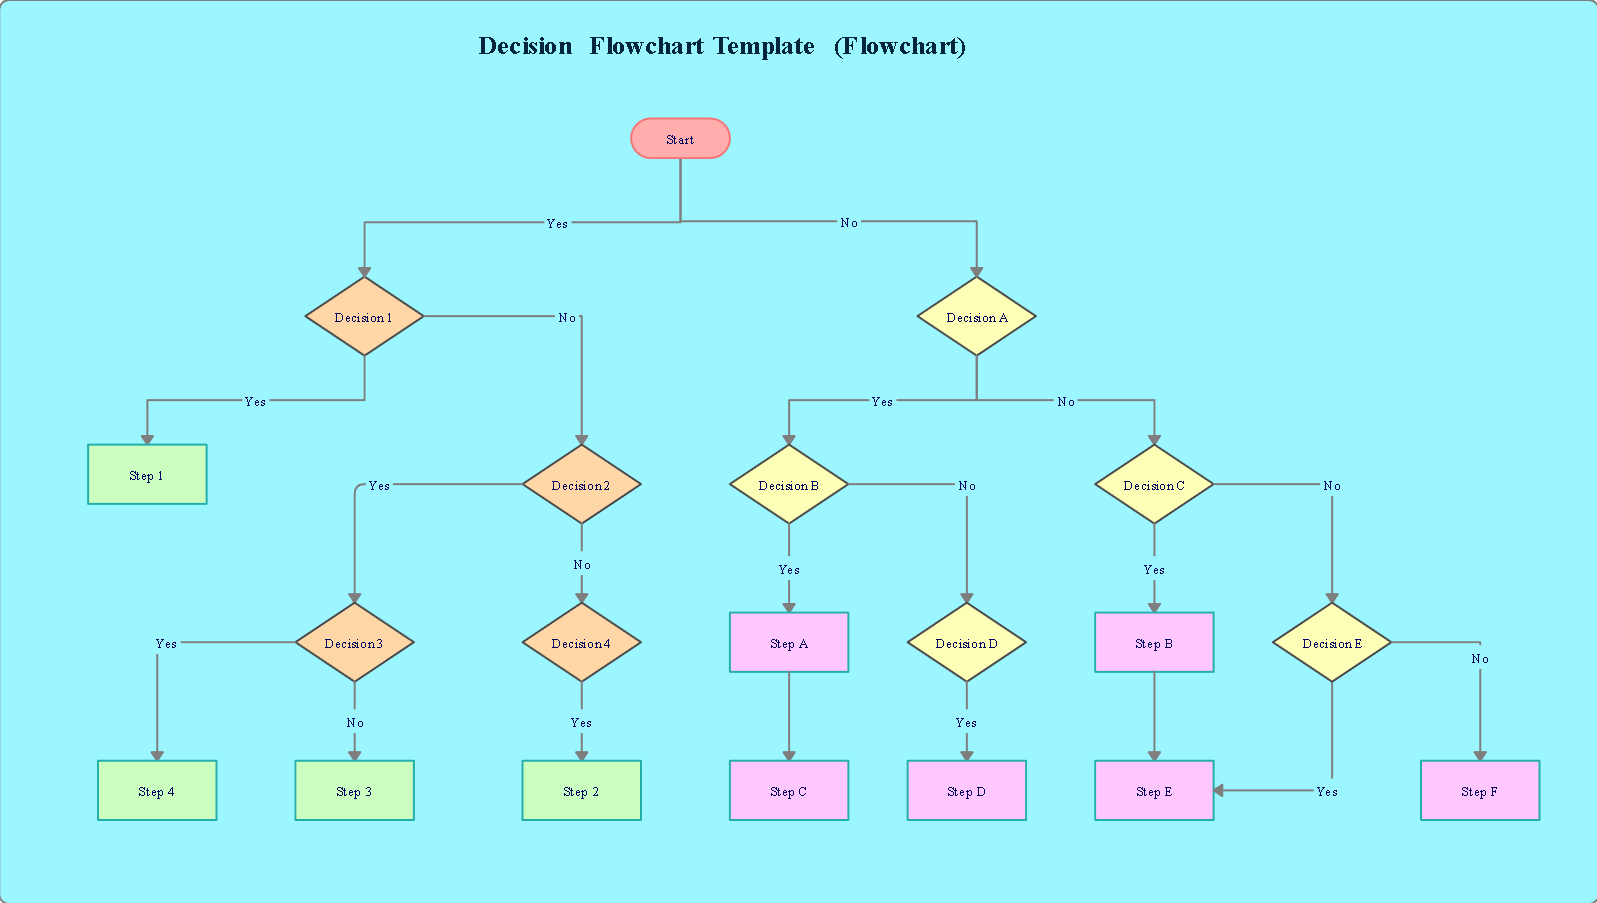<br><br>

CART (Classification and Regression Trees) is a key algorithm for building types of decision trees. It identifies the feature that maximized information gain at each node, creating mode homogenous subsets. This process improves classification accuracy and ensures decision points lead to distinct, meaningful categories.<br><br>

Types of decision trees, like classification trees, are used in practical applications such as medical diagnostics to identify diseases from patient data, and customer segmentation for personalized marketing. Their simplicity, effectiveness, and ability to provide clear decision rules make them an invaluable tool for predictive tasks and actionable insights.<br><br>

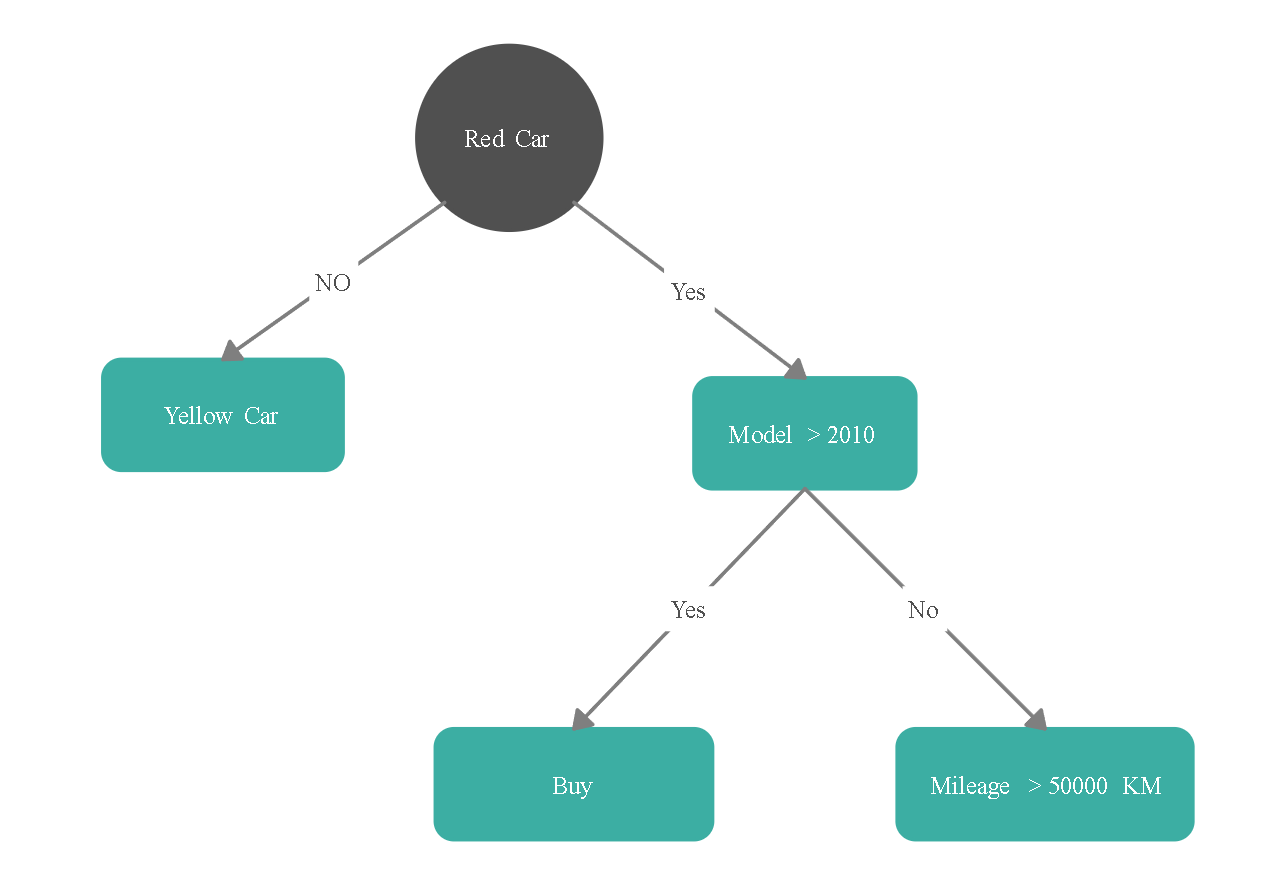<br><br>

Regression Trees -> Predicting Continuous Values<br><br>

Regression trees predict continous numerical outcome, making them essential for predictive modeling. Unlike classification trees, which handle categorical data, regression trees forecast values like future sales or property prices by analyzing historical datasets and identifying key patterns for accurate predictions.<br><br>

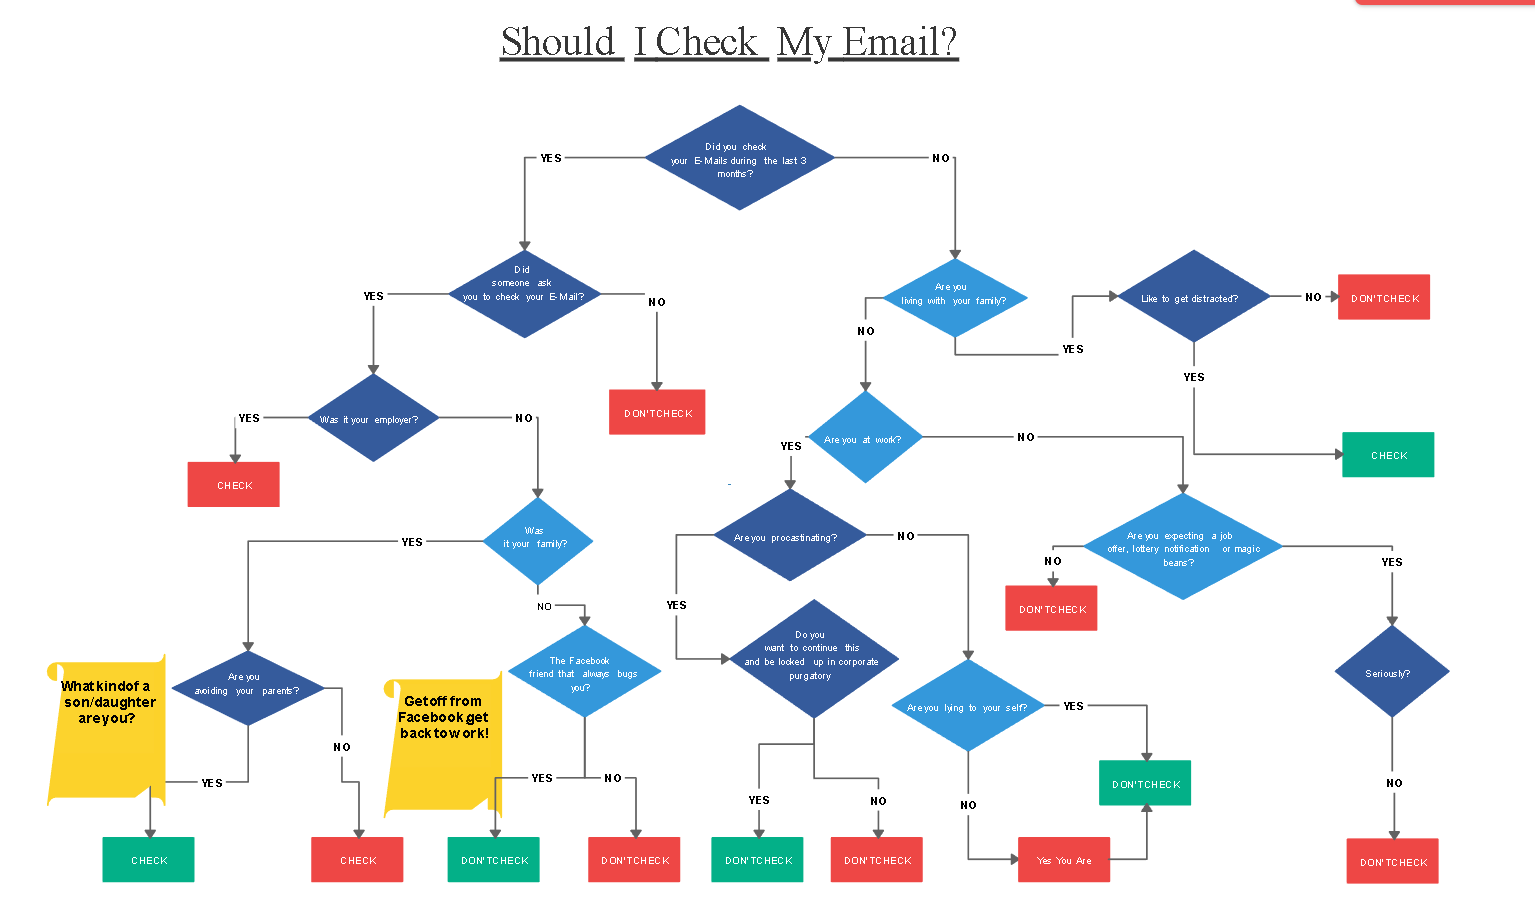<br><br>

CHAID (Chi-squared Automatic Interaction Detector) enhances regression trees by performing multiple splits to refine predictions for continous values. The Reduction in Variance algorithm further improves accurary by focusing on key nodes.<br><br>

Choosing the right type of decision tree - classification for categories and regression for continous data - boosts prediction effectiveness. Creately simplifies this with interactive tools to visualize and build complex models, helping businesses improce decisions and strategic planning with a clear, data-driven framework.<br><br>

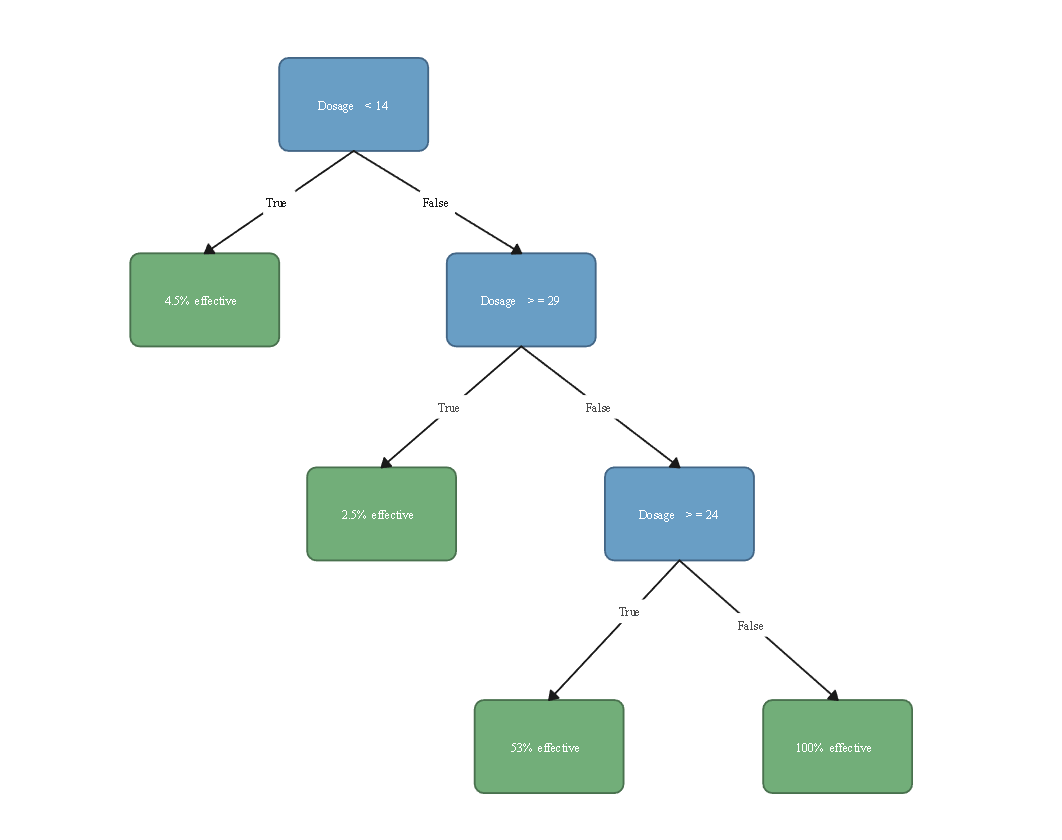<br><br>

11  Types of Decision Tree Algorithms<br><br>

1. Decision Tree Algorithms for Classification<br><br>

Decision tree algorithms are widely used in classification tasks, providing a clear and intuitive way to make data-driven decisions by splitting data into hierarchical branches based on feature values.<br><br>

1.1. ID3 (Iterative Dichotomiser 3)<br><br>

- Purpose -> Classification<br>
- Splitting Criterion -> Information Gain (based on entropy)<br>
- Feature -> Works well with categorical data<br>
          -> Less efficient for continuous data<br><br>

1.2. C4.4<br><br>

- Purpose -> Classification<br>
- Splitting Criterion -> Gain Ratio (an enhancement of Information Gain)<br>
- Features -> Handles both categorical and continours data<br>
           -> Includes pruning techniques to prevent overfitting<br>
           -> Manages missing data effectively<br><br>

1.3. CART (Classification and Regression Trees)<br><br>

- Purpose -> Classification and Regression<br>
- Splitting Criterion -> Gini Impurity for Classification<br>
- Features -> Binary Splits Only<br>
           -> Straightforwatds yet highly effective for most used cases<br><br>

1.4. CHAID (Chi-Squared Automatic Interaction Detector)<br><br>

- Purpose -> Classification<br>
- Splitting Criterion -> Chi-Squared statistical significance test<br>
- Features -> Allows multi-way splits
           -> Commonly used for market research and segmentation<br><br>

1.5. QUEST (Quick, Unbiased, Efficient Statistical Tree)<br><br>

- Purpose -> Classification<br>
- Splitting Criterion -> Statostical tests to ensure unbiased splits<br>
- Features -> Reduces computational time<br>
           -> Effective for unbiased decision-making<br><br>

2. Decision Tree Algorithms for Regression<br><br>

Decision tree algorithms for regression predict continous outcomes by partitioning data into segments and fitting simple models, such as averages, within each region of the tree.<br><br>

2.1. CART (Classification and Regression Trees)<br><br>

- Purpose -> Regression and classification<br>
- Splitting Criterion -> Mean Squared Error (MSE) for regression<br>
- Features -> Binary splits at each node<br>
           -> Handles bath tasks efficiently<br><br>

2.2. MARS (Multivariate Adaptive Regression Splines)<br><br>

- Purpose -> Regression<br>
- Features -> Uses hinge functions to model non-linearity<br>
           -> A flexible extension of regression trees<br><br>

3. Ensemble and Advanced Decision Tree Algorithms<br><br>

Ensemble and advances decision tree algorithms combine multiple decision trees or enhance traditional methods to improve prediction accuracy and handle complex datasets effectively.<br><br>

3.1. Random Forest<br><br>

- Purpose -> Classification and regression<br>
- Feature -> Combines multiple decision trees for better accuracy<br>
          -> Reduces overfitting by aggregating results<br><br>

3.2. XGBoost (eXtreme Gradient Boosting)<br><br>

- Purpose -> Classification and Regression<br>
- Features -> Ensemble of gradient-boosted decision trees<br>
           -> Highly scalable and efficient<br>
           -> Built-in regularization to prevent overfitting<br><br>

3.3. LightGBM (Light Gradient Boosted Machine)<br><br>

- Purpose -> Classification and Regression<br>
- Features -> Faster and more memory-efficient than XGBoost<br>
           -> Uses histogram-based splitting techniques<br><br>

3.4. H2O GBM<br><br>

- Purpose -> Classification and Regression<br>
- Features -> Distributed and scalable for large datasets<br>
           -> High-speed implementation of gradient-boosted trees<br><br>

Types of Decision Trees: Strenghts and Limitations<br><br>

Type -> Classification Tree<br>
Strenghts -> Excellent for catgorizing data into predefined classes<br>
          -> Easy to interprent results<br>
          -> Handles both categorical and numerical data<br>
Limitations -> Car overfit with complex datasets<br>
            -> Struggles with continous target values<br><br>

Type -> Regression Tree<br>
Strenghts -> Ideal for predicting numerical or continous outputs<br>
          -> Handles non-linear relationships effectively<br>
Limitations -> Sensitive to small changes in data<br>
            -> May require pruning to avoid overfitting<br><br>

Type -> CART (Classification and Regression Tree)<br>
Strenghts -> Combines classification and Regression capabilities<br>
          -> Supports binary splitting for better decision-making<br>
Limitations -> May produce biased splits if not properly tunes<br>
            -> Computationally expensive for large datasets<br><br>

Type -> ID3 (Iterative Dichotomiser 3)<br>
Strenghts -> Uses information gain for accurate feature selection<br>
         -> Suitable for small datasets with categorical values<br>
Limitations -> Cannot handle numerical data directly<br>
            -> Prone to overfitting with noise in the data<br><br>

Type -> Random Forest<br>
Strenghts -> Reduces overfitting by averaging multiple decision trees<br>
          -> Works well with larger datasets<br>
          -> Handles missing values effectively<br>
Limitations -> Difficult to interpret individual trees<br>
            -> Requires significant computational power<br><br>

Type -> C4.5
Strenghts -> Improves upes ID3 by handling both categorical and continous data<br>
          -> Prunes trees to avoid overfitting<br>
Limitations -> Computationally intensive for large datasets<br>
            -> Less accurate on highly noisy data<br><br>

Type -> CHAID (Chi-Squared Automatic Interaction Detector)<br>
Strenghts -> Great for market segmentation and statistical analysis<br>
          -> Handles multi-way splits, improving interpretability<br>
Limitations -> Not ideal for small datasets<br>
            -> Assumes linear relationships<br><br>

Type -> Decision Stump<br>
Strenghts -> Simple and fast for one-level decision-making<br>
          -> Works well as a weak learner in ensemble models<br>
Limitations -> Limited predictive accuracy<br>
            -> Overly simplictic for complex datasets<br><br>

Decision trees are a foundational tool in machine learning and data analysis, offering unique strenghts and some limitations. A clear understaing of these aspects is essential for making informed decisions about their application.<br><br>

Advantages of Decision Trees<br><br>

1. Simplicity and Interpretability -> Decision trees are highly intuitive, presenting data in visual, starightforward format. Their transparency allows even non-technical stakeholders to easily interpret the results without delving into complex algorithms.<br>
2. Versatility -> Decision trees can handle a wide range of tasks, including classification and regression problems. They are equally effective with both numerical and categorical data, making them applicable across various domains.<br>
3. No Need for Feature Scaling -> Unlike many machine learning models, decision trees do not require scaling or normalization. They can process raw, unprocessed data directly, saving time and effort in preprocessing.<br><br>

Disadvantages of Decision Trees<br><br>
1. Overfitting -> Decision trees are prone to overfitting, especially when they become too complex. This can result in capturing noise instead of actual data patterns, reducing performance on new, unseen data.<br>
2. Bias Towards Multi-level Features -> Trees may favour features with multiple levels or categories, potentially skewing predictions and reducing model accuracy.<br>
3. Instability -> Decision trees are highly sensitive to small changes in the dataset. Even monor variations can lead to significant changes in the tree structure, making them less robust in dynamic data environments.<br><br>

Comparing Types of Decision Trees with Other Algorithms<br><br>

Compared to other machine learning models, deicison trees excel in their interpretability and accessibility. While more complex algorithms like neural networks may perform better on intricate, non-linear relationships, they lack the transparency of decision trees. For example:<br><br>

- Decision Trees -> Ideal for scenarios requiring explainability, such as regulatory compliance<br>
- Neural Networks -> Better suited for complex problems but opeate as black-box models with less interpretability<br><br>

Neural Network Template: <br><br>

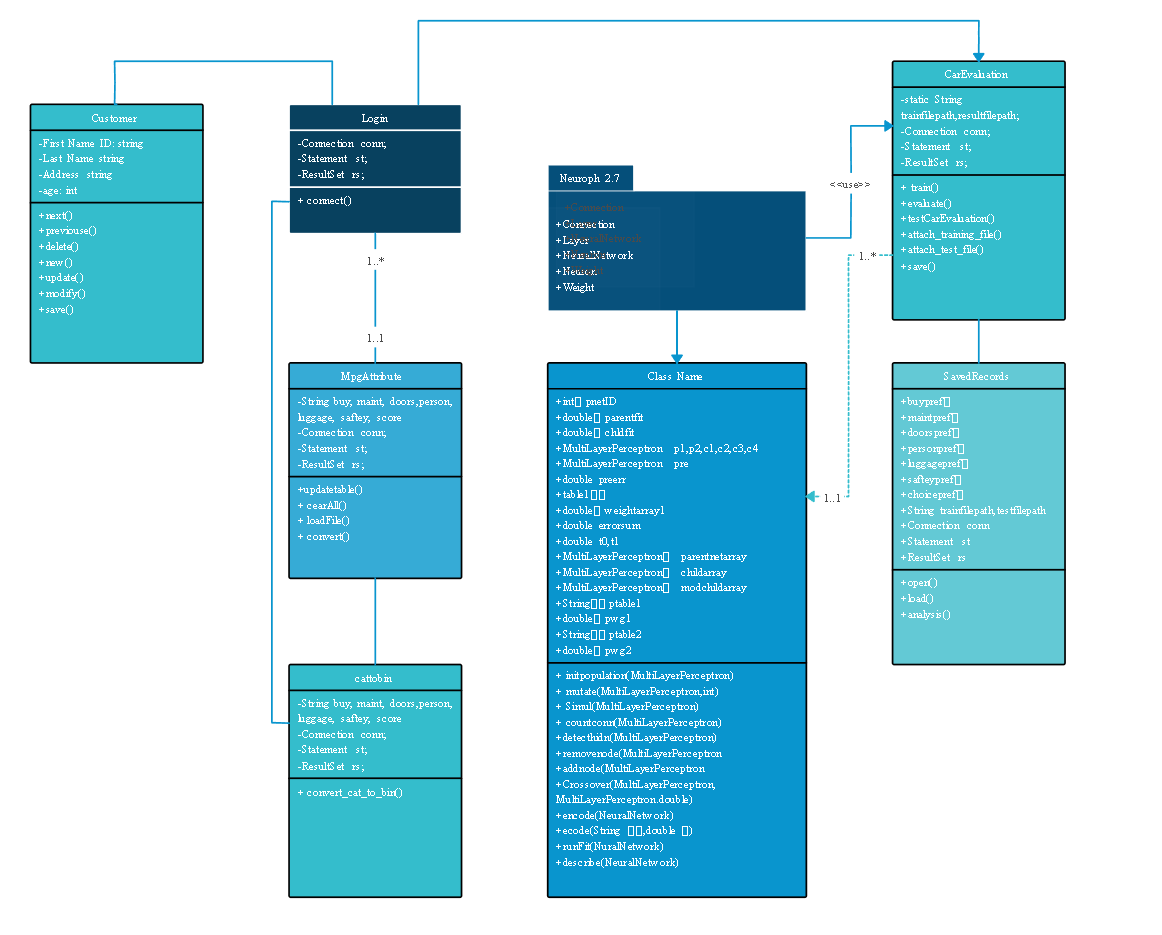<br><br>

Here is a comparative table between decision trees and neural networks:<br><br>

Aspect:<br>
Decision Trees -> High - Easy to understand and visualize<br>
Neural Networks -> Low - Operates as a balck-box model<br><br>

Complexity Handling:<br>
Decision Trees -> Effective for simpler, linear to moderately complex problems<br>
Neural Networks -> Excels at handling complex, non-linear relationships<br><br>

Feature Requirements:<br>
Decision Trees -> No feature scaling needed<br>
Neural Networks -> Required feature scaling and normalization<br><br>

Training Time:<br>
Decision Trees -> Faster to train, especially with smaller datasets<br>
Neural Networks -> Slower to train, particularly with large datasets<br><br>

Overfitting:<br>
Decision Trees -> Prone to overfitting, especially with deep trees<br>
Neural Networks -> Less prone to overfitting, but can occur with improper tuning<br><br>

Robustness:<br>
Decision Trees -> Sensitive to small changes in data (instability)<br>
Neural Networks -> More stable in handling noise and large datasets<br><br>

Use Cases:<br>
Decision Trees -> Ideal for applications requiring clear explanation (e.g., regulatory compliace)<br>
Neural Networks -> Suited for complex prediction tasks (e.g., image recognition, speech processing)<br><br>

Performance:<br>
Decision Trees -> Adequate for simpler tasks, may underperform with high-dimensional data<br>
Neural Networks -> High performance on complex, high-dimensional data<br><br>

Deployment:<br>
Decision Trees -> Easier to implement and maintain<br>
Neural Networks -> Requires more resources and infrastructure for deployment<br><br>

Practical Applications of Types of Decision Trees<br><br>

Decision trees are particularly valuable in situation where explainability is crucial. For instance, in regulatory compliance, they outperform black-box methos like deep learning by providing clear, interpretable decision-making structures.<br><br>

While decision trees have some limitations, their ease of use, interpretability, and adaptability make them indispensable in many analytical toolkits. Exploring algorithm comparisons and understang specific use cases can help maximize their potential in solving data-driven problems.<br><br>

Healthcare and Diagnostic Tools<br><br>

In healthcare, decision trees are essential for improving diagnostic accuracy and personalizing treatment. By analysing variables like patient history, symptoms, and lab results, decision trees help in predicting diseases and tailoring treatment paths. This enhances diagnostic precision, optimizes resources allocation, and supports healthcare systems like health informatics and electronic health recors. Tools like Creately's Decision Tree Example help healthcare proffesionals visualize and compare treatment options, promoting collaboration for intergrated care.<br><br>

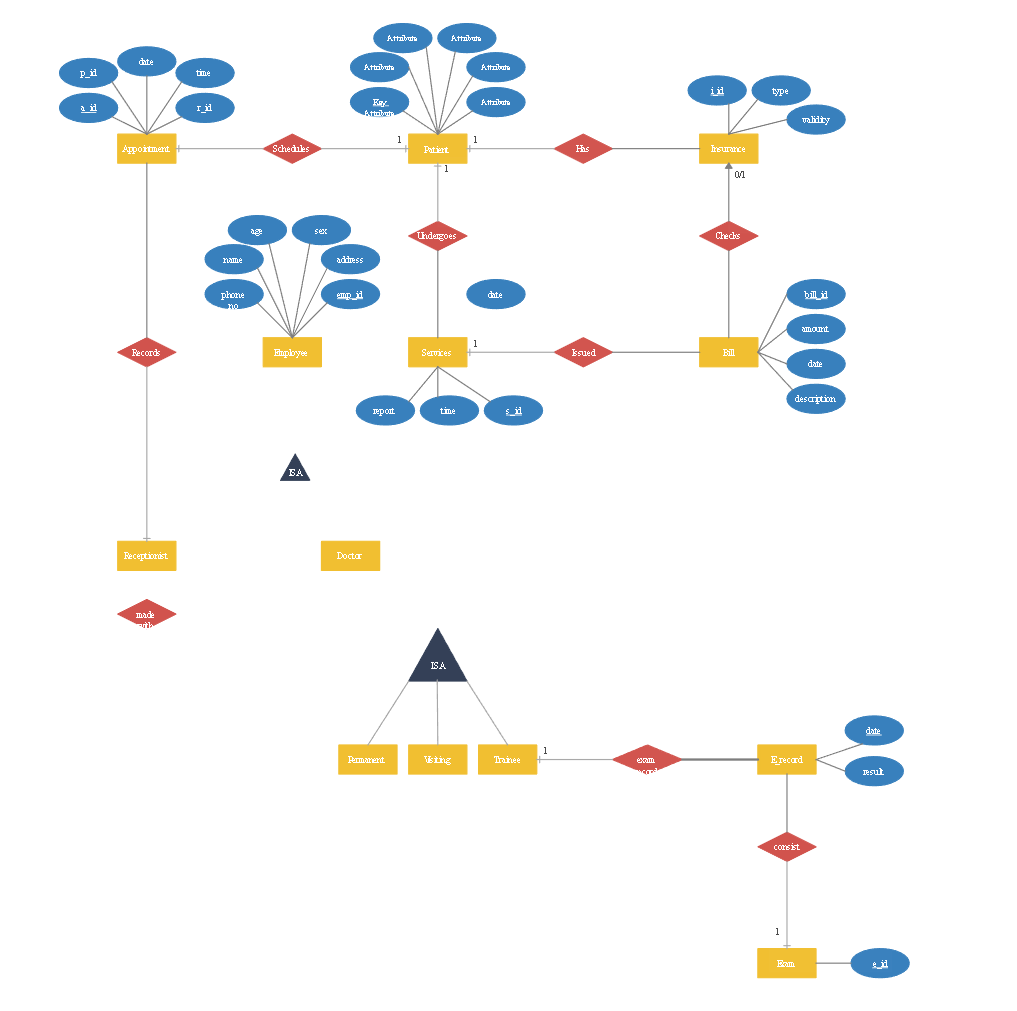<br><br>

Financial Modelling and Risk Assesment<br><br>

Decision trees are vital in finance for risk management and decision-making, especially in credit scoring, investment decisions, and asset pricing. They break down complex financial scenarios into manageble components, helping analysts assess risks and returns. In credit scoring, decision trees forecase default probabilities, aiding informed lending decisions. Financial institutions use them for protofolio optimization and regulatory compliance. Tools like Creately's Decision Tree Analysis Template assists in financial modelling with interactive dashboards, streamlining strategy development.<br><br>

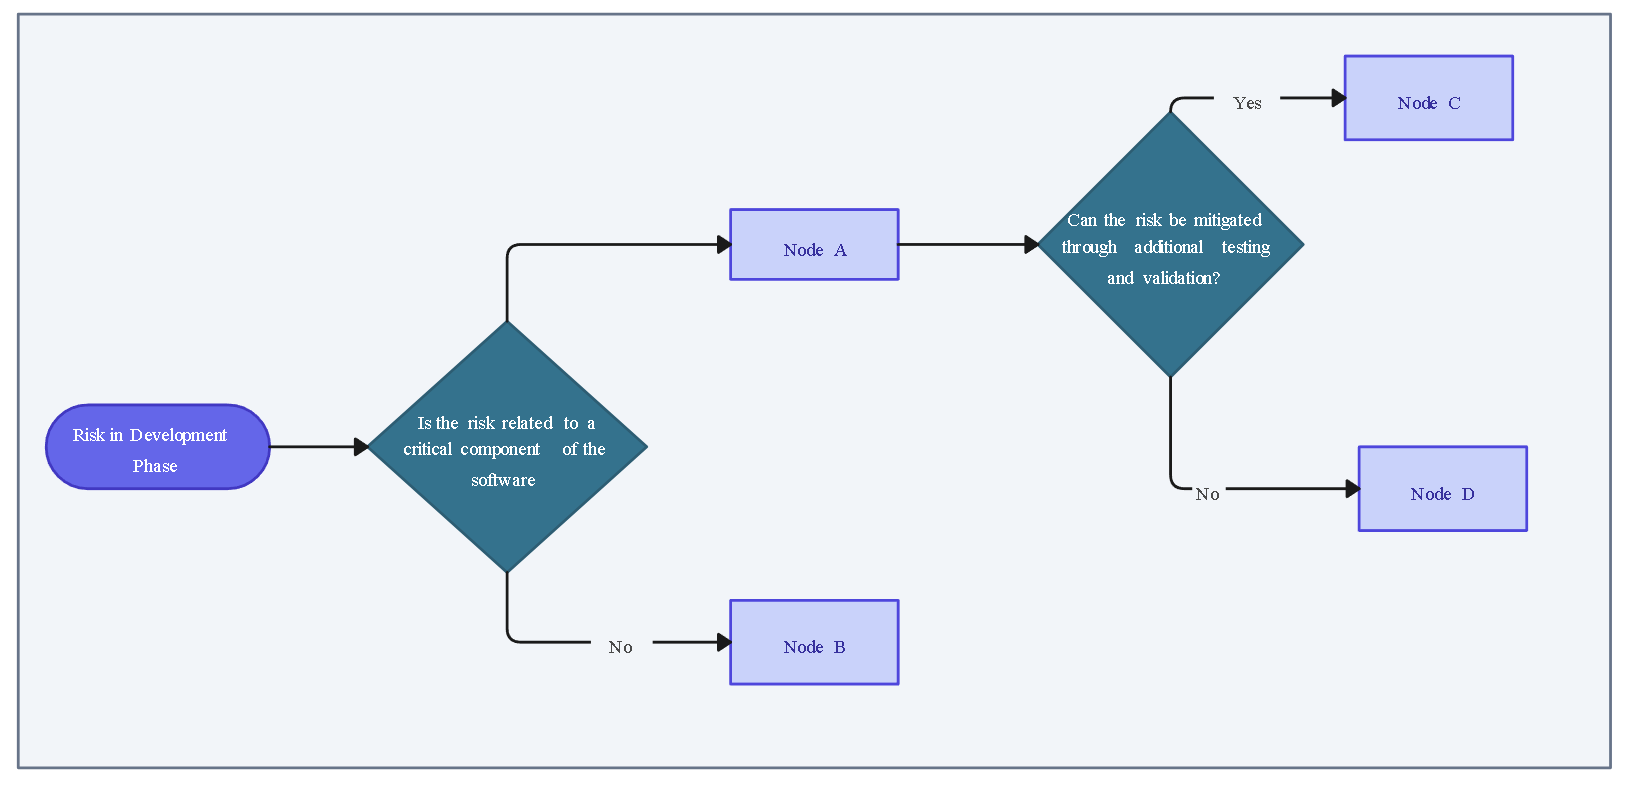<br><br>

Marketing and Customer Segmentation<br><br>

In marketing, decision trees help businesses analyse customer behaviour, segment audiences, and tailor marketing campaigns. By examining purchasing habits, demographics, and preferences, decision trees predict customer responses to producs and services. This allows marketers to optimize engagement strategies and targer advertising for maximum impact. Creately's visual workspace aids marketers in constructing and interpreting decision paths alighning with business objectives.<br><br>

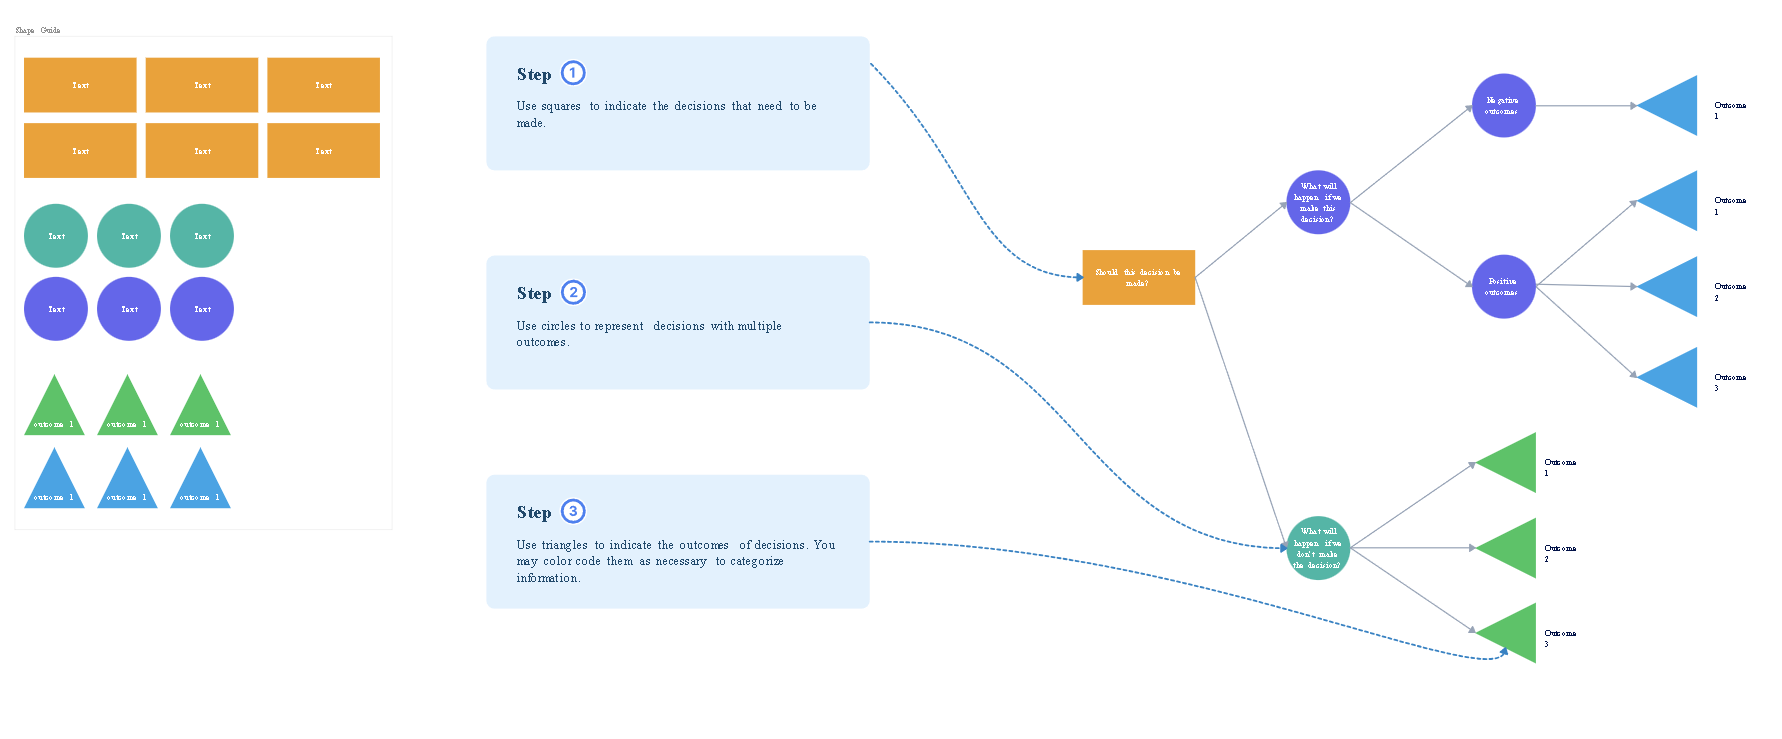<br><br>

Conclusion<br><br>

Decision trees provide a simple yet porwerful approach to machine learning and decision-making. Their strenghts in interpretability, versatility, and ease of use make them an essential tool in fields like healthcare, finance, and marketing. Despite some limitations, such as overfitting and instability, decision trees remain invaluable for clear, data-driven decision-making.<br><br>

https://creately.com/guides/types-of-decision-trees/<br><br>

Decision Tree Algorithms for Classification<br><br>

1.1. ID3 (Iterative Dichotomiser 3)<br><br>

The Iterative Dichotomiser 3 (ID3) algorithm is a decision tree learning algorithm used for solving classification problems. It contructs a tree by selecting attributes that maximize Information Gain, which is computed using entropy. ID3 follows a greedy, top-down recursive strategy to split the dataset until the classification becomes pure or no attributes retain. Let's see some key concepts:<br><br>

- Decision Tree Learning -> Represents classification logic using a tree structure<br>
- Entropy -> Measures impurity or randomness in the target variable<br>
- Information Gain -> Quantifies reduction in entropy after a split<br>
- Greedy Appoach -> Chooses the best split at each step without backtracking<br>
- Cetegorical Attributes -> Originally designed for categorical features<br><br>

Working<br>
Let's see how ID3 works<br><br>

1. Initialize the Dataset -> The algorithm begins by taking the complete training dataset along with the target class attribute. At this stage, all input features are considered as potential candidates for splitting<br><br>

2. Compute Entropy of Target Attribute -> Entropy is calculated for the target class to measure the level of impurity or randomness present in the dataset. This value acts as a baseline for evaliating future splits<br><br>

3. Calculate Information Gain for Each Attribute -> For every input attribute, the dataset is split based on its distinct values and entropy is compared for each subset. Information gain is then calculated as the reduction in entropy caused by splitting on that attribute<br><br>

4. Select the Best Attribute for Splitting -> The attribute with the highest information gain is selected as the decision node because it best separates the data into homogonous classes<br><br>

5. Partition the Dataset -> The dataset is divided into multiple subsets based on the values of the selected attribute. Each subset corresponds to one branch of the decision tree.<br><br>

6. Create Child Nodes Recursively -> The same process of entropy calculation and information gain evaluation is recursively applied to each subset to grow the decision tree further.<br><br>

7. Check Stopping Conditions -> The resursion stops if all instances in a subset belong to the same class, if no attributes are left for further splitting or if the subset becomes empty.<br><br>

8. Assign Class Labels to Leaf Nodes -> When a stopping condition is met, a lead node is created and assigned the majority class label of the corresponding subset.<br><br>

Implementation<br><br>

Step 1: Import the required libraries<br><br>

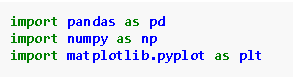<br><br>

Step 2: Entropy Function<br><br>

- Unique class labels and their frequencies are extracted from the target column<br>
- Class probabilities are computed using frequency counts<br>
- Entropy is calculated using the standard entropy formula<br>
- This function measures impurity at any node in the decision tree<br><br>

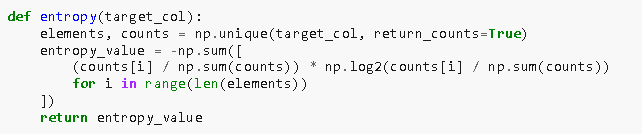<br><br>

Step 3: Information Gain Function<br><br>

- Entropy of the fill dataset is calculated before splitting<br>
- The daset is split based on each unique value of the selected feature<br>
- Entropy is computed for every subset created bu the split<br>
- A weighted sum of subset of entropies is calculated<br>
- Information gain is obtained by subtracting weighted entropy from total entropy<br><br>

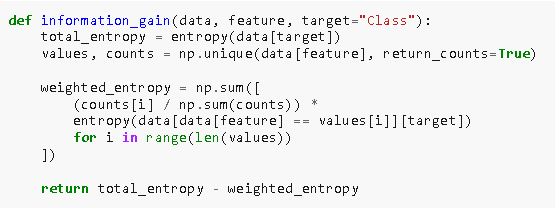<br><br>

Step 4: Recursive ID3 Tree Construction<br><br>

- This function builds the decision tree recursively<br>
- It takes the current dataset original dataset, ramaining features and target column<br><br>

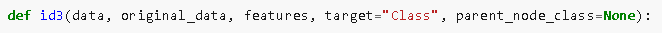<br><br>

Step 5: Handle Stopping Conditions and Mojority Class<br><br>

- Stops recursion when data becomes pure<br>
- Handles empty subsets safely<br>
- Assigns majority class when no features remain<br><br>

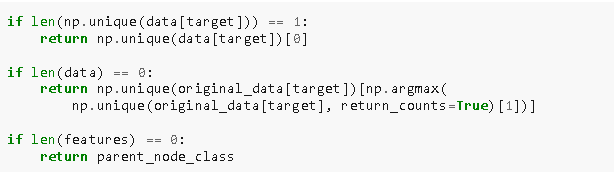<br><br>

Step 6: Select Best Feature and Split Dataset<br><br>

- Identifies the most frequent class for fallback prediction<br>
- Selects the attribute with the highest information gain<br>
- Initializes the decision node<br><br>

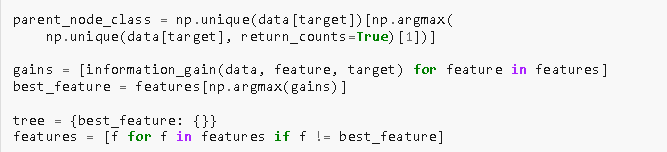<br><br>

Step 7: Recursive Subtree Generation<br><br>

- Splits the data based on feature values<br>
- Recursively builds child nodes<br>
- Attaches sebtrees to the main decision node<br><br>

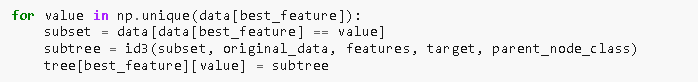<br><br>

Step 8: Execute Model and Output Tree<br><br>

- Dataset is defines and processed<br>
- ID3 algorithm is executed<br>
- Final decision tree is printed as a nested dictionary<br><br>

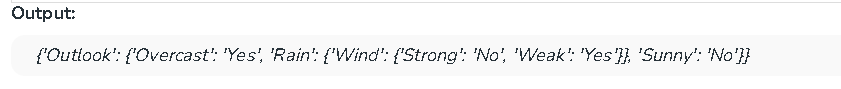<br><br>

Applications<br><br>

- Medical Disgnosis Systems -> ID3 is used to classify diseases based on symptoms and patient attributes by generating interpretable decision rules<br>
- Credit Risk Assessment -> Banks and financial institutions use ID3 to decide loan approval or rejection based on applicat features<br>
- Customer Segmentation -> It helps group customers based on behaviour, preferences or demographics for targeted marketing<br>
- Educational Analytics -> ID3 is applied to predict student performance, dropout risk or grade classification<br>
- Expert Systems -> The algorithm is widely used in rule-based expert systems where decision transparency is required<br><br>

Advantages:<br><br>

- Simple and Easy to Understand -> The tree structure and decision rules produced by ID3 are intuitive and human-readable<br>
- Automatic Feature Selection -> ID3 automatically selects the most informative attributes using information gain<br>
- Non-Parametric Nature -> It does not assume any prior data distributiong, making it flexible for different datasets<br>
- Efficient for Small Datasets -> ID3 performs well and trains quickly on small to medium-sized datasets<br>
- Rule Extraction Capability -> The generated decision tree can be easily converted into if-else rules<br><br>

Limitations<br><br>

- Overfitting Problem -> ID3 does not include pruning, which can lead to overly complex trees<br>
- Bias Toward Multi-Valued Attributes -> Attributes with many distinct values tend to have higher information gain, causing biased splits<br>
- Handling of Continous Data -> ID3 cannot derectly handle numerical attributes without prior discretization<br>
- Sensitivity to Noise -> Noisy or Inconsistent data can significanlty affect the quality of the decision tree<br>
- Greedy Learning Strategy -> The algorithm chooses locally optimal splits and may miss the globally optimal tree<br><br>

https://www.geeksforgeeks.org/machine-learning/iterative-dichotomiser-3-id3-algorithm-from-scratch/<br><br>

Entropy<br><br>

In machine learning, entropy represents uncertanty or randomness in a dataset. Higher entropy means more uncertanty, while lower entropy means more predictable data. It is used to evaluate how well a split separates data into more predictible groups.<br><br>

For large data sets, entropy calculations can quckly become a computational bottleneck that slows down your entire workflow.<br><br>

Fortunately, modern tools make it possible to scale these calculations well, and the right implementation strategies can change your approach to entropy. With the proper oundation and computational resources, you can use entropy's full potential in all your AI projects.<br><br>

Breakdown<br><br>

- Shannon entropy measure uncertanty in data using , with higher values indicating more unpredictable outcomes<br>
- Decision trees use information gain to select optimal splits, reducing entropy at each node for better classification accuracy<br>
- Cross-entropy loss functions guide neural network training by penalizing confident wrong predictions exponentially more than uncertain ones<br>
- GPU acceleration reduces entropy calculation time from hours to minutes for large datasets and complex model training<br>
- Thunder Compute provides cost savings on GPU instances with one-click deployment for entrpoy-based machine learning workflows<br><br>

Shannon Entropy Fundamentals<br><br>

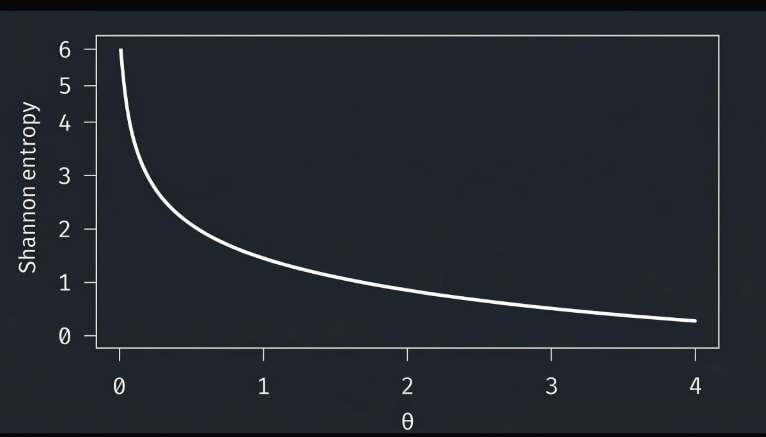<br><br>

Shanning entropy stands as the cornerstone of information theory, fundamentally changing how we mesure undertanty and information content in data. Claude Shannon's 1948 paper introduced this new concept that quantifies the average level of undertanty associated with a variables's potential states.<br><br>

https://www.thundercompute.com/blog/shannon-entropy-machine-learning-guide<br><br>


1.2. C4.5<br><br>

1.3. CART (Classification and Regression Trees)<br><br>

1.4. CHAID (Chi-squared Automatic Interaction Detector)<br><br>

1.5. QUEST (Quick, Unbiased, Efficient Statistical Tree)<br><br>

Decision Tree Algorithms for Regression<br><br>

2.1. CART (Classification and Regression Trees)<br><br>

2.2. MARS (Multivariate Adaptive Regression Splines)<br><br>

Ensemble and Advances Decision Tree Algorithms<br><br>

3.1. Random Forest<br><br>

3.2. XGBoost (eXtreme Gradient Boosting)<br><br>

3.3. LightGBM (Light Gradient Boosted Machine)<br><br>

3.4. H2O GBM<br><br>

In [6]:
# ============================================================
# DECISION TREE
# Easy to interpret. No scaling needed. Can overfit.
# Look for high training accuracy but lower test accuracy (overfitting).
# ============================================================

from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(random_state=42)
tree.fit(X_train, y_train)  # no scaling needed

y_pred_tree = tree.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_tree))


Decision Tree Accuracy: 0.9518716577540107


Test Accuracy: 0.9519
Train Accuracy: 1.0000
If Train >> Test, the model is overfitting.

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.91      0.95        94
           1       0.92      0.99      0.95        93

    accuracy                           0.95       187
   macro avg       0.95      0.95      0.95       187
weighted avg       0.95      0.95      0.95       187



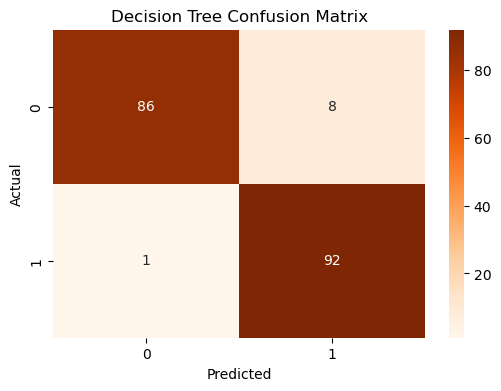

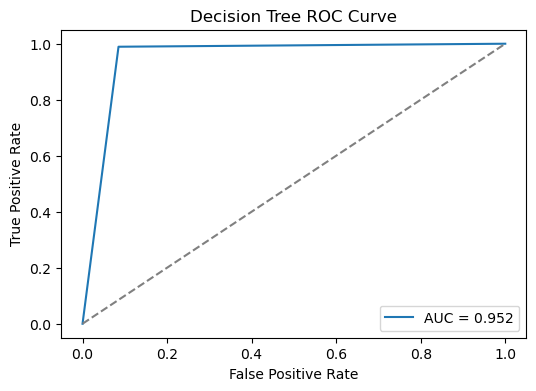

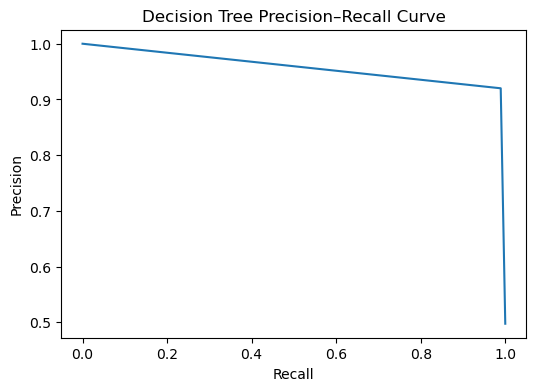


Feature Importance:
                          Feature  Importance
9           Water_Intake (liters)    0.506969
2                      Height (m)    0.201165
8                  Fat_Percentage    0.112306
1                     Weight (kg)    0.103372
6        Session_Duration (hours)    0.038151
7                 Calories_Burned    0.010022
12                            BMI    0.008910
4                         Avg_BPM    0.005646
10  Workout_Frequency (days/week)    0.004302
15                   Workout_Yoga    0.004033
13                   Workout_HIIT    0.003585
3                         Max_BPM    0.000869
0                             Age    0.000670
5                     Resting_BPM    0.000000
11               Experience_Level    0.000000
14               Workout_Strength    0.000000


C:\Users\Admin\AppData\Local\Temp\ipykernel_14172\2820223216.py:127: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x='Importance', y='Feature', palette='autumn')


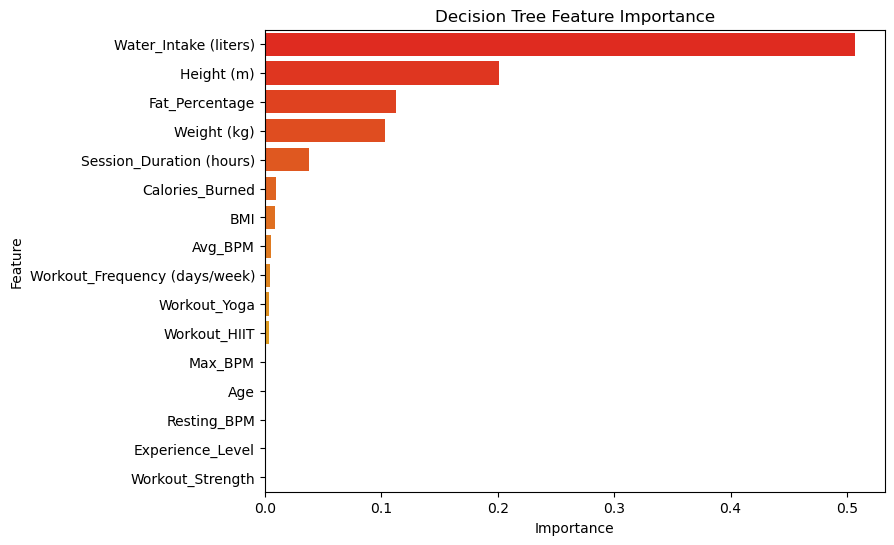

In [16]:
# ============================================================
#   DECISION TREE — FULL MODEL EVALUATION SUITE
#   This cell trains the Decision Tree and evaluates it using:
#     ✔ Accuracy
#     ✔ Classification Report
#     ✔ Confusion Matrix
#     ✔ ROC Curve + AUC
#     ✔ Precision–Recall Curve
#     ✔ Feature Importance (unique to trees)
#     ✔ Overfitting check (train vs test accuracy)
#   Every section includes comments explaining what to look for.
# ============================================================

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_curve, auc, precision_recall_curve
)
import pandas as pd

# ------------------------------------------------------------
# 1. Train the Decision Tree model
# ------------------------------------------------------------
# Trees do NOT require scaling.
tree = DecisionTreeClassifier(random_state=42)
tree.fit(X_train, y_train)

# Predictions
y_pred_tree = tree.predict(X_test)
y_prob_tree = tree.predict_proba(X_test)[:, 1]  # needed for ROC/PR curves


# ------------------------------------------------------------
# 2. Accuracy Score (Test Set)
# ------------------------------------------------------------
# Accuracy = proportion of correct predictions.
# Trees often overfit, so accuracy alone is not enough.
test_accuracy = accuracy_score(y_test, y_pred_tree)
print(f"Test Accuracy: {test_accuracy:.4f}")


# ------------------------------------------------------------
# 3. Overfitting Check — Train Accuracy vs Test Accuracy
# ------------------------------------------------------------
# If train accuracy is much higher than test accuracy,
# the tree is memorising the training data (overfitting).
train_accuracy = accuracy_score(y_train, tree.predict(X_train))
print(f"Train Accuracy: {train_accuracy:.4f}")
print("If Train >> Test, the model is overfitting.\n")


# ------------------------------------------------------------
# 4. Classification Report
# ------------------------------------------------------------
# Shows precision, recall, and F1-score for each class.
# Look for balanced values across both classes.
print("Classification Report:")
print(classification_report(y_test, y_pred_tree))


# ------------------------------------------------------------
# 5. Confusion Matrix
# ------------------------------------------------------------
# Shows EXACTLY where the model is making mistakes.
# Diagonal = correct predictions.
# Off-diagonal = errors.
cm = confusion_matrix(y_test, y_pred_tree)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges')
plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# ------------------------------------------------------------
# 6. ROC Curve + AUC Score
# ------------------------------------------------------------
# ROC curve shows how well the model separates the two classes.
# AUC close to 1.0 = excellent.
fpr, tpr, thresholds = roc_curve(y_test, y_prob_tree)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], linestyle='--', color='grey')
plt.title("Decision Tree ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()


# ------------------------------------------------------------
# 7. Precision–Recall Curve
# ------------------------------------------------------------
# Useful when one class is less common.
# Look for curves that stay high (good precision)
# and far right (good recall).
precision, recall, thresholds = precision_recall_curve(y_test, y_prob_tree)

plt.figure(figsize=(6,4))
plt.plot(recall, precision)
plt.title("Decision Tree Precision–Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()


# ------------------------------------------------------------
# 8. Feature Importance (unique to Decision Trees)
# ------------------------------------------------------------
# Shows which features the tree used most for splitting.
# Higher importance = more influence on predictions.
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': tree.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\nFeature Importance:")
print(importance_df)

plt.figure(figsize=(8,6))
sns.barplot(data=importance_df, x='Importance', y='Feature', palette='autumn')
plt.title("Decision Tree Feature Importance")
plt.show()
